### EMPLOYEE BURN-OUT PREDICTION WITH MACHINE LEARNING

#### Brief history of employee burn out
Employee burnout is a state of chronic physical, emotional, and mental exhaustion caused by prolonged workplace stress. It often results from excessive workload, lack of control, insufficient recognition, poor work-life balance, or limited support from management

Organizational Impact

- Lower productivity: Employees deliver less output and work less efficiently.

- Higher turnover rates: Burnout pushes skilled employees to resign, raising recruitment and training costs.

- Poor workplace culture: Low morale spreads, leading to disengagement across teams.

- Increased healthcare costs: Stress-related illnesses raise medical expenses.

- Decline in service quality: Customer satisfaction and organizational reputation suffer.

#### Importance of Using Data to Predict Employee Burnout

* Early Identification of Risks: Data allows organizations to detect patterns and signals of burnout before they become severe, enabling timely interventions.

- Improved Employee Well-being: Predictive insights help HR and managers design better wellness programs, workload adjustments, and support systems tailored to employee needs.

- Reduced Turnover and Retention of Talent By preventing burnout, organizations can keep valuable employees, reducing recruitment and training costs.

- Enhanced Productivity and Performance Employees who are less stressed and engaged perform better, boosting overall organizational effectiveness.

- Evidence-based Decision: Making Data-driven approaches remove guesswork, helping leaders implement policies and strategies based on real evidence rather than assumptions.

- Cost Savings: Preventing burnout reduces costs linked to absenteeism, healthcare, errors at work, and lost productivity.

- Stronger Organizational Culture: Using data to understand and address burnout fosters a supportive workplace, improving morale and trust between staff and management.

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading training data
df_train = pd.read_csv('train.csv')

df_train.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [3]:
df_train.columns = df_train.columns.str.lower() #converting columns name to lowercases
df_train.columns= df_train.columns.str.replace(' ', '_', regex = False) # remove all spaces

In [4]:
#performing evaluatory data analysis
print(df_train.shape) # shape of the datasets
print('-'*30)
print('Total null values :\n',df_train.isna().sum()) #checking our null values
print('-'*30)
print('number of duplicate :\n', df_train.duplicated().sum())
print('-'*30)
df_train.info()
print('-'*30)



(22750, 9)
------------------------------
Total null values :
 employee_id                0
date_of_joining            0
gender                     0
company_type               0
wfh_setup_available        0
designation                0
resource_allocation     1381
mental_fatigue_score    2117
burn_rate               1124
dtype: int64
------------------------------
number of duplicate :
 0
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           22750 non-null  object 
 1   date_of_joining       22750 non-null  object 
 2   gender                22750 non-null  object 
 3   company_type          22750 non-null  object 
 4   wfh_setup_available   22750 non-null  object 
 5   designation           22750 non-null  float64
 6   resource_allocation   21369 non-null  float64
 7   ment

In [5]:
df_train = df_train.dropna(subset ='resource_allocation')

#filling null values of premiunm Amount, Previous Claims  and annual income with median as it keeps data shape more accurate
df_train[['mental_fatigue_score','burn_rate']] = df_train[['mental_fatigue_score', 'burn_rate']].fillna(df_train[['mental_fatigue_score', 'burn_rate']].median())

In [6]:
print('Total null values after cleaning :\n',df_train.isna().sum()) #checking our null values handling missing values
print('-'*30)
print(df_train.shape) # shape of the datasets after handling missing values

Total null values after cleaning :
 employee_id             0
date_of_joining         0
gender                  0
company_type            0
wfh_setup_available     0
designation             0
resource_allocation     0
mental_fatigue_score    0
burn_rate               0
dtype: int64
------------------------------
(21369, 9)


In [7]:
df_train.describe() #univarate analysis on categorical column

,designation,resource_allocation,mental_fatigue_score,burn_rate
count,21369.000000,21369.000000,21369.000000,21369.000000
mean,2.178904,4.481398,5.745351,0.452097
std,1.136036,2.047211,1.832588,0.193475
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.700000,0.320000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,6.900000,0.580000
max,5.000000,10.000000,10.000000,1.000000


In [8]:
df_train.describe(include = ['object']).T #univarate analysis on categorical column

,count,unique,top,freq
employee_id,21369,21369,fffe32003000360033003200,1
date_of_joining,21369,366,2008-01-06,84
gender,21369,2,Female,11197
company_type,21369,2,Service,13960
wfh_setup_available,21369,2,Yes,11550


Exploratory Data Analysis of the datasets

In [9]:
cat_df =df_train.select_dtypes(exclude = ['int64', 'float64']) #categorical datas
num_df = df_train.select_dtypes(exclude = ['object']) #numerical datas

<Axes: xlabel='burn_rate', ylabel='Count'>

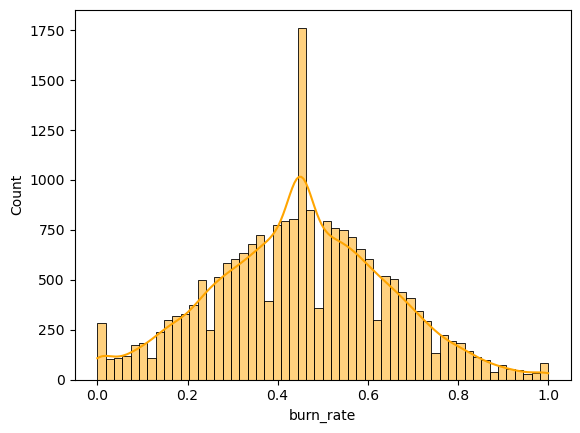

In [59]:
sns.histplot(df_train["burn_rate"], kde=True, color="orange") #histogram showing burn rate

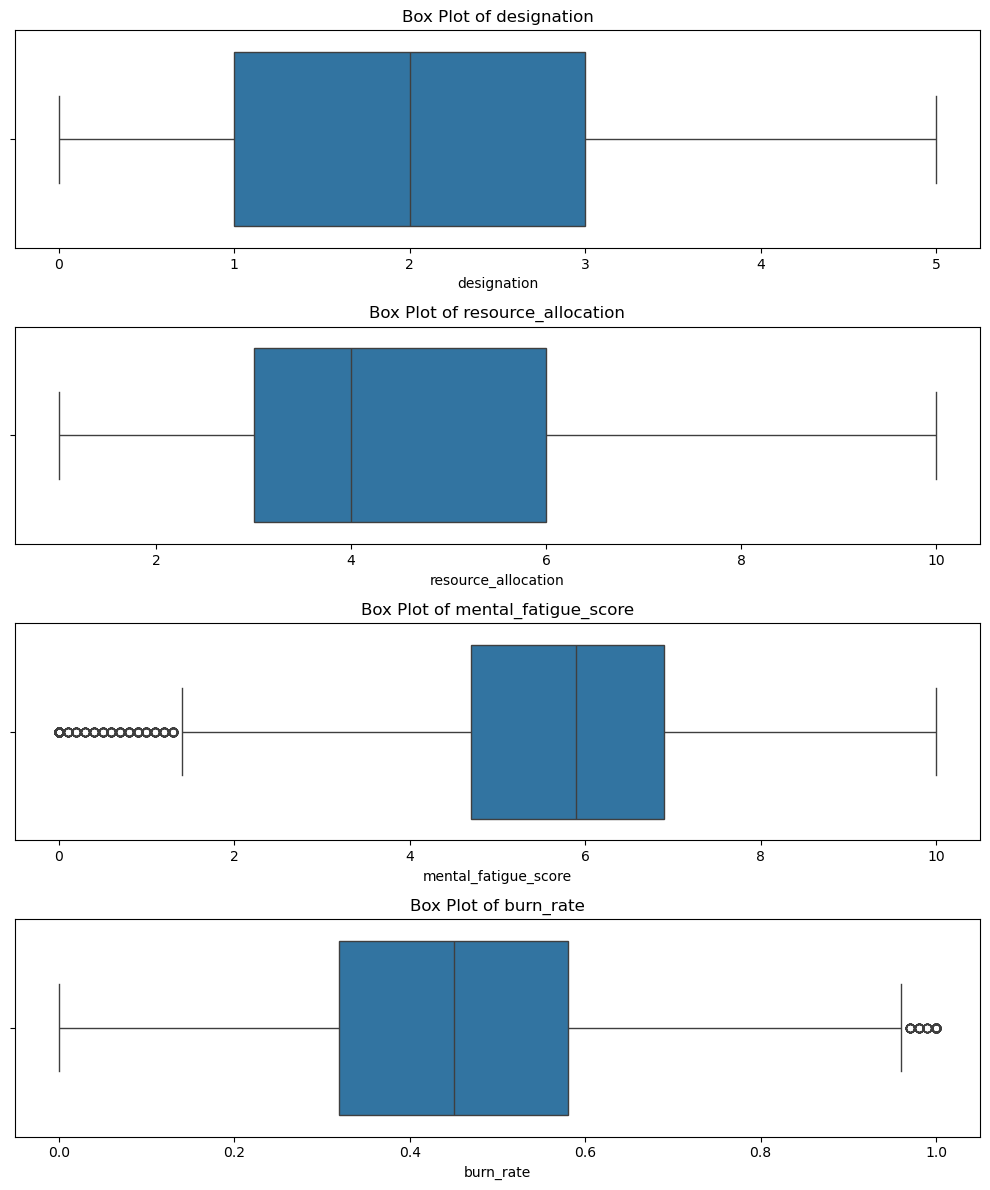

In [10]:
#multivariate analysis
#box plot for each numerical data

# Number of numeric columns
num_cols = num_df.shape[1] # 1 signify column

# Set up subplots
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, num_cols * 3))

# Plot each boxplot
for i, col in enumerate(num_df.columns):
    sns.boxplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

### r

## Insights from the above box pot the
- box pot of designation is between the range of 1-6
- box plot of resource allocation is between the range of 3-6
- box plot of mental faigue is between 5-7
- box plot of burn rate is between 0.3-0.6

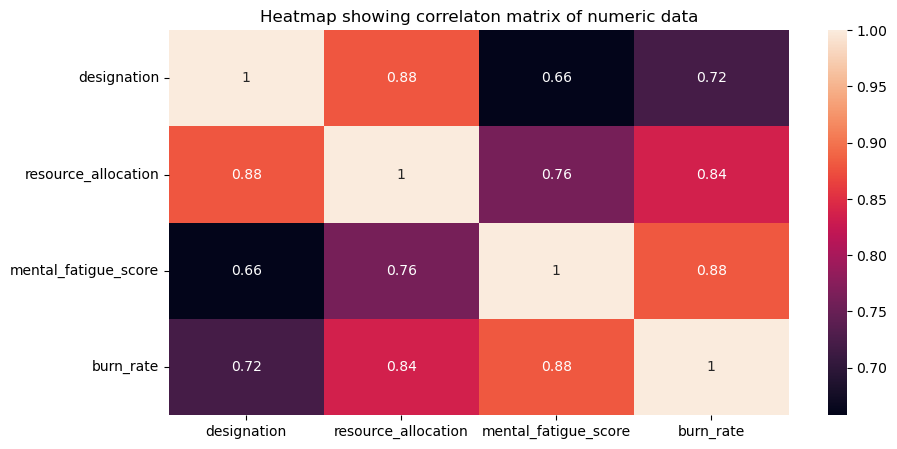

In [11]:
""" calculating  the correlation matrix  of numeric data using heat map"""

num_df_corr = num_df.corr()
plt.figure(figsize = (10,5))

sns.heatmap(num_df_corr,linecolor='green', cmap=None, annot = True)
plt.title('Heatmap showing correlaton matrix of numeric data')
plt.show()

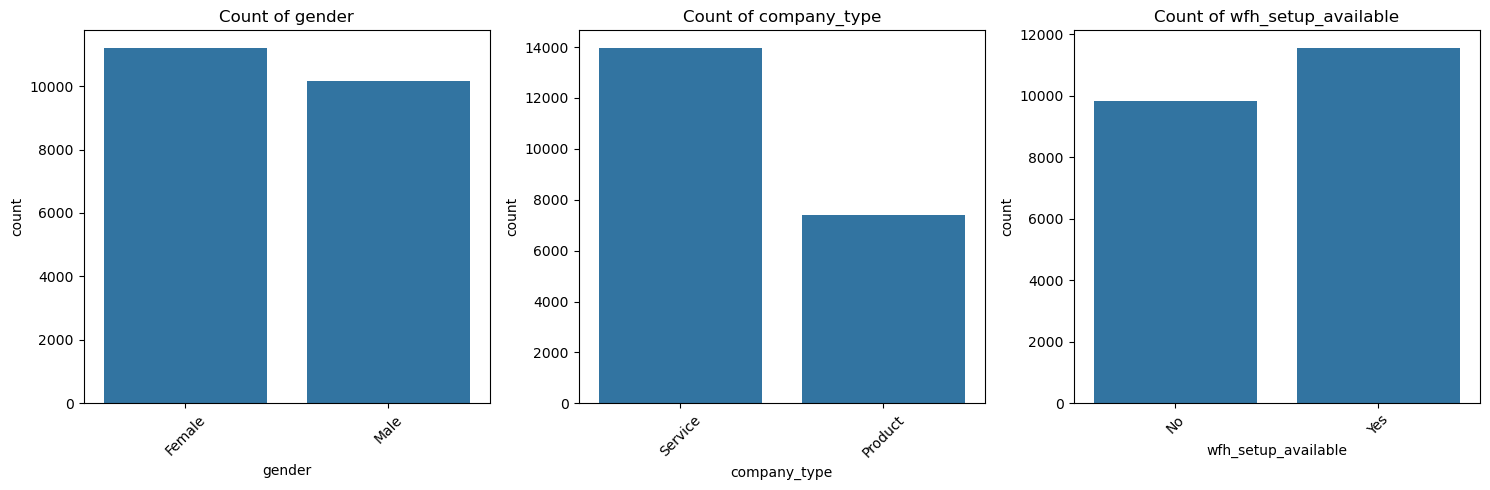

In [12]:
#multiple count plot
cols = ["gender", "company_type", "wfh_setup_available"]  

fig, axes = plt.subplots(1, len(cols), figsize=(15, 5))

for i, col in enumerate(cols):
    sns.countplot(data=df_train, x=col, ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

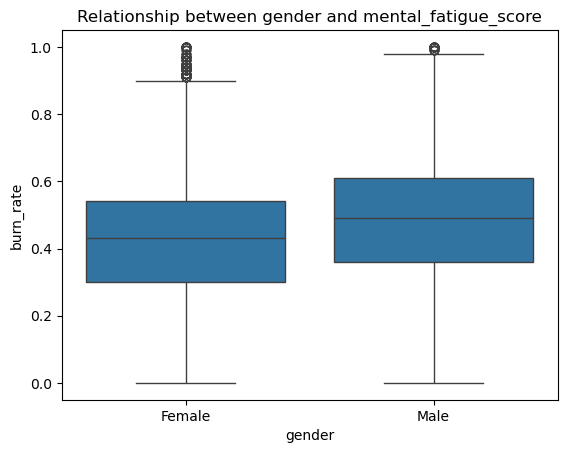

In [13]:
""" ploing a boxplot showing the relationship of age to the mental faitgue score"""
sns.boxplot(data = df_train, y ="burn_rate", x ="gender")
plt.title('Relationship between gender and mental_fatigue_score')
plt.show()

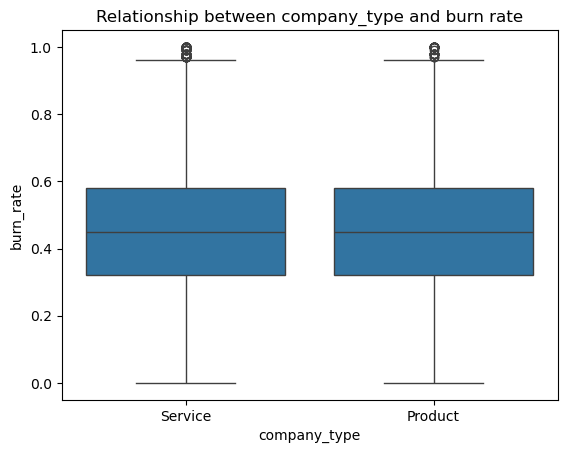

In [14]:
""" ploing a boxplot showing the relationship of burn rate to the company name"""
sns.boxplot(data = df_train, y ="burn_rate", x ="company_type")
plt.title('Relationship between company_type and burn rate')
plt.show()

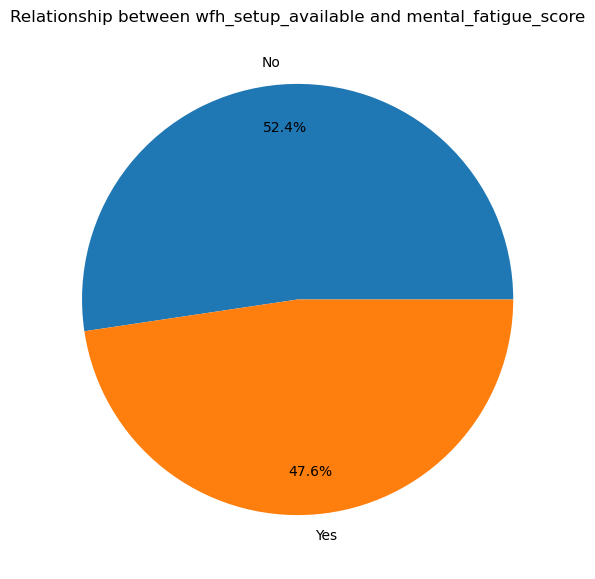

In [15]:
" checking insight of the relationship between policy type and premium amount using pie chart"
mental_wfh = df_train.groupby('wfh_setup_available')['burn_rate'].sum()

x=mental_wfh.index
y=mental_wfh.values

plt.figure(figsize=(7, 7))
plt.pie(y, labels=x, autopct='%1.1f%%', pctdistance = 0.8,)
plt.title('Relationship between wfh_setup_available and mental_fatigue_score')
plt.show()

In [16]:
#inserting new features


# Convert the transaction date to datetime
df_train['date_of_joining'] = pd.to_datetime(df_train['date_of_joining'])

df_train["tenure_months"] = (pd.to_datetime("today") - df_train["date_of_joining"]).dt.days // 30 #converting to month

df_train["tenure_years"] = (pd.to_datetime("today") - df_train["date_of_joining"]).dt.days // 365 #converting to years




In [17]:
df_train.head()


,employee_id,date_of_joining,gender,company_type,wfh_setup_available,designation,resource_allocation,mental_fatigue_score,burn_rate,tenure_months,tenure_years
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16,205,16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36,203,16
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20,204,16
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52,207,17
5,fffe3300350037003500,2008-11-26,Male,Product,Yes,2.0,4.0,3.6,0.29,203,16


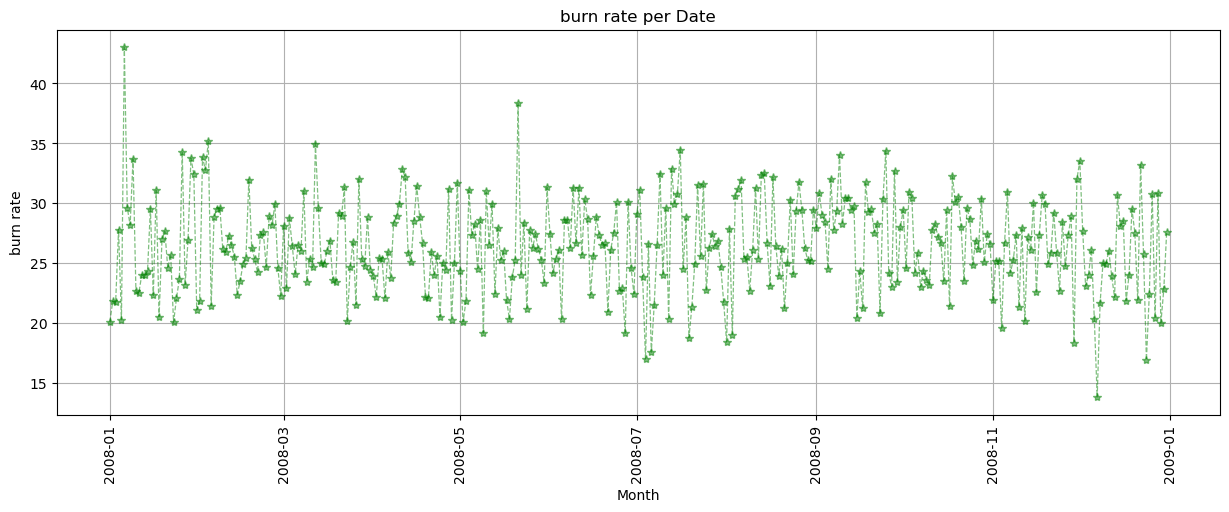

In [18]:
# Group by 'date of joining' and sum 'burn rate'
date_burn_rate = df_train.groupby('date_of_joining')['burn_rate'].sum()

# Plotting
plt.figure(figsize=(15, 5))

x=date_burn_rate.index
y=date_burn_rate.values

plt.plot(x, y, color='green', linestyle='--',
         linewidth=0.9, marker="*", alpha=0.5)
plt.xticks(rotation=90)
plt.title('burn rate per Date')
plt.xlabel("Month")
plt.ylabel("burn rate")
plt.grid(True)
plt.show()

### insight from above line plot
- September showed a higher burnout rate compared to the rest, and December had the lowest burnout rate maybe due to the fact that it is an holiday period

In [52]:
df_train=df_train.drop(['date_of_joining', 'employee_id'], axis = 1) #not needed anymore

In [53]:
df_test = pd.read_csv('test.csv')

df_test.columns = df_test.columns.str.lower() #converting columns name to lowercases
df_test.columns= df_test.columns.str.replace(' ', '_', regex = False) # remove all spaces

# Convert the transaction date to datetime
df_test['date_of_joining'] = pd.to_datetime(df_test['date_of_joining'])

df_test["tenure_months"] = (pd.to_datetime("today") - df_test["date_of_joining"]).dt.days // 30 #converting to month

df_test["tenure_years"] = (pd.to_datetime("today") - df_test["date_of_joining"]).dt.days // 365 #converting to years

df_test = df_test.drop(['date_of_joining', 'employee_id'], axis = 1) #not needed

#tallying the test sets to the traun sets

In [54]:
# Features (X) and Target (y)
X=df_train.drop("burn_rate", axis=1)
y= df_train["burn_rate"]

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
""" importing our traintest split"""
from sklearn.model_selection import train_test_split

from sklearn.metrics import (r2_score,
                            mean_squared_error,
                            mean_absolute_error,
                           
                                
)
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline


In [23]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
) #y_valid acts as my y_test and X_valid acts as my X_test

In [24]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [25]:
#importing xgboost
import xgboost as xgb
from xgboost import XGBRegressor


In [55]:
# Using pipeline to preprocess our data


num_data = X_train.select_dtypes(["int64", "float64"]).columns.to_list()

cat_data = X_train.select_dtypes("object").columns.to_list()



""" using column transformer to combine the two pipes"""
# Preprocessing for numerical and categorical data

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine them
combined = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_data),
        ("cat", categorical_transformer, cat_data)
    ]
)



"""models for training"""
rf = RandomForestRegressor(),
lr=LinearRegression()
Xg = XGBRegressor()

""" rf TRAINING"""
pipe_line_rf = Pipeline(
    steps=[
        ("preprocessing", combined),
        ("pca", PCA(n_components=8, svd_solver ="arpack")),
        ("model",RandomForestRegressor())
        
    ]
)

"""lr"""
pipe_line_lr = Pipeline(
    steps=[
        ("preprocessing", combined),
        ("pca", PCA(n_components=8, svd_solver ="arpack")),
        ("model", lr)
        
    ]
)

"""xgboost TRAINING"""
pipe_line_xg = Pipeline(
    steps=[
        ("preprocessing", combined),
        ("pca", PCA(n_components=8, svd_solver ="arpack")),
        ("model", Xg)
        
    ]
)



In [45]:
PIPELINES = [pipe_line_lr, pipe_line_rf, pipe_line_xg]
for pipe in PIPELINES:
    pipe.fit(X_train, y_train)

In [46]:
"""PREDICTION OF TESTING DATA"""
y_pred_rf = pipe_line_rf.predict(X_valid)
y_pred_xg = pipe_line_xg.predict(X_valid)
y_pred_lr = pipe_line_lr.predict(X_valid)

In [31]:
#evaluating our models using  RMSE, MAE, R2_score
print('This is the MAE of Random Forest Regressor =', mean_absolute_error(y_valid, y_pred_rf))
print('This is the MSE of Random Forest Regressor =', mean_squared_error(y_valid, y_pred_rf))
print('This is the R2 of Random Forest Regressor =', r2_score(y_valid, y_pred_rf))
print('This is the RMSE of Random Forest Regressor =', np.sqrt(metrics.mean_squared_error(y_valid, y_pred_rf)))

print("==============================================")

print('This is the MAE of XGBOOST Regressor =', mean_absolute_error(y_valid, y_pred_xg))
print('This is the MSE of XGBOOST Regressor=', mean_squared_error(y_valid, y_pred_xg))
print('This is the R2 of XGBOOST Regressor =', r2_score(y_valid, y_pred_xg))
print('This is the RMSE of XGBOOST Regressor =', np.sqrt(metrics.mean_squared_error(y_valid, y_pred_xg)))

print("==============================================")

print('This is the MAE of Linear Regression =', mean_absolute_error(y_valid, y_pred_lr))
print('This is the MSE of Linear Regression=', mean_squared_error(y_valid, y_pred_lr))
print('This is the R2 of Linear Regression =', r2_score(y_valid, y_pred_lr))
print('This is the RMSE of Linear Regression =', np.sqrt(metrics.mean_squared_error(y_valid, y_pred_lr)))

print("==============================================")

This is the MAE of Random Forest Regressor = 0.056741308969295925
This is the MSE of Random Forest Regressor = 0.006008420855924876
This is the R2 of Random Forest Regressor = 0.8404611800776332
This is the RMSE of Random Forest Regressor = 0.07751400425681075
This is the MAE of XGBOOST Regressor = 0.054691457510847793
This is the MSE of XGBOOST Regressor= 0.005605637778773671
This is the R2 of XGBOOST Regressor = 0.8511560928266356
This is the RMSE of XGBOOST Regressor = 0.07487080725338595
This is the MAE of Linear Regression = 0.055904048749329006
This is the MSE of Linear Regression= 0.005980993072773109
This is the R2 of Linear Regression = 0.8411894573175347
This is the RMSE of Linear Regression = 0.07733688041790353


#### from the above evaluation XGBOOST Regressor has a better model performance with lowest MAE/RMSE, highest R²

- XGBoost has many tunable parameters (learning rate, max depth, subsample, colsample_bytree, n_estimators, etc.), which can significantly improve performance.

- It also handles non-linearities and feature interactions better.

- Random Forest Regressor is also strong and close behind and can be tuned too, but its improvements are usually smaller compared to XGBoost

In [47]:
from sklearn.model_selection import RandomizedSearchCV

# Base model
#xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Hyperparameter grid
param_grid = {
   "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

scoring = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'R2': 'r2'
}

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=pipe_line_xg,
    param_grid=param_grid,
    cv=3,
    scoring= scoring,
    refit='R2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best Score: 0.8619383997269745


In [48]:
# Best tuned pipeline
best_model = grid_search.best_estimator_

# Make predictions on test data
y_pred_test = best_model.predict(df_test)


In [77]:
pip install shap



   ---------------------------------------- 0.0/545.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.3 kB ? eta -:--:--
   ---- ----------------------------------- 61.4/545.3 kB 1.7 MB/s eta 0:00:01
   ---- ----------------------------------- 61.4/545.3 kB 1.7 MB/s eta 0:00:01
   ---- ----------------------------------- 61.4/545.3 kB 1.7 MB/s eta 0:00:01
   ---- ----------------------------------- 61.4/545.3 kB 1.7 MB/s eta 0:00:01
   ---- ----------------------------------- 61.4/545.3 kB 1.7 MB/s eta 0:00:01
   ---- ----------------------------------- 61.4/545.3 kB 1.7 MB/s eta 0:00:01
   -------- ----------------------------- 122.9/545.3 kB 343.4 kB/s eta 0:00:02
   -------- ----------------------------- 122.9/545.3 kB 343.4 kB/s eta 0:00:02
   -------- ----------------------------- 122.9/545.3 kB 343.4 kB/s eta 0:00:02
 

In [65]:
output = pd.DataFrame({
    "predicted_burn_rate": y_pred_test
})
output.to_csv("burnout_predictions.csv", index=False)

In [66]:
!pip install joblib

In [49]:
""" SAVING MODEL FOR FUTURE USE usinh joblib or pickle"""
import joblib, pickle

# Save best model
joblib.dump(best_model, "best_burn_out_model.pkl")



['best_burn_out_model.pkl']

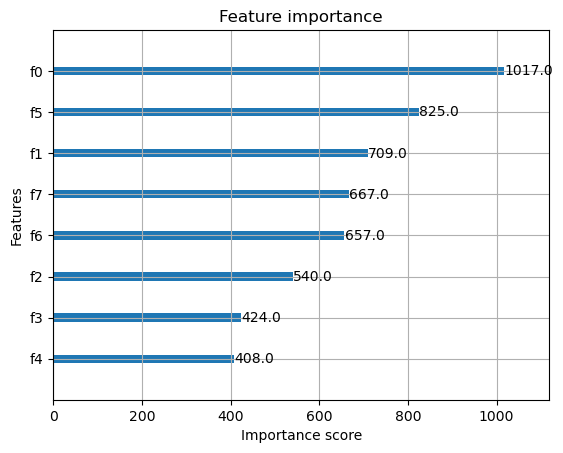

In [50]:
# loading my pipeline best model:
import joblib
pipeline = joblib.load("best_burn_out_model.pkl")

# XGBoost from pipeline
model = pipe_line_xg.named_steps['model']  

#  feature importances
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model)
plt.show()


In [51]:
# Get feature names after preprocessing
feature_names = (
    pipe_line_xg.named_steps['preprocessing'].get_feature_names_out()
)

# Get PCA object
pca = pipe_line_xg.named_steps['pca']

# Create a dataframe of PCA loadings
pca_components = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[f"f{i}" for i in range(pca.n_components_)]
)

#o get features name that contribute mostly to the model
for i in range(pca.n_components_):
    print(f"\nTop features for f{i}:")
    print(pca_components.iloc[i].abs().sort_values(ascending=False).head())


Top features for f0:
num__resource_allocation        0.595230
num__designation                0.569468
num__mental_fatigue_score       0.541343
cat__wfh_setup_available_Yes    0.106123
cat__wfh_setup_available_No     0.106123
Name: f0, dtype: float64

Top features for f1:
num__tenure_years            0.707091
num__tenure_months           0.707083
num__mental_fatigue_score    0.005387
num__resource_allocation     0.003565
num__designation             0.002388
Name: f1, dtype: float64

Top features for f2:
cat__gender_Female              0.656823
cat__gender_Male                0.656823
cat__wfh_setup_available_No     0.191614
cat__wfh_setup_available_Yes    0.191614
num__designation                0.165803
Name: f2, dtype: float64

Top features for f3:
cat__company_type_Service       0.594439
cat__company_type_Product       0.594439
cat__wfh_setup_available_No     0.369279
cat__wfh_setup_available_Yes    0.369279
num__designation                0.122890
Name: f3, dtype: float64

Top fe

In [56]:
df_train.to_csv("train_clean.csv", index=False)
df_test.to_csv("test_clean.csv", index=False)


#### Insights
* Model & Methods
#### Algorithms used (Linear Regression, XGBoost, RandomForest).
#### Data preprocessing (encoding, scaling, handling missing values).

* Evaluation metrics (RMSE, MAE, R², MSE).

* Key Findings

- Most important features:  mental_fatigue_score, resource_allocation, designation, work from home availability.

- High mental fatigue strongly correlates with higher burnout.

- Long tenure without resources increases burnout.

- Remote work availability shows a small but positive effect in reducing burnout.

#### Predictions

- Predicted burnout risk ranges (low, medium, high).

#### Recommendations

Workload management: Monitor employees with high mental_fatigue_score.

Resource allocation: Ensure fair distribution of tasks and tools.

Career progression: Employees at high designation but limited resources face higher burnout.

Remote work: Encourage flexible WFH setups to ease burnout.

#### Conclusion

The model provides actionable insights to improve employee well-being.

Organization should prioritize interventions targeting mental fatigue and resource management.